# NUDGE — `design()`: from diagnosis to **prescription**

**The headline thesis.** NUDGE's other capabilities *diagnose* — which knob (threshold /
gain / ceiling) a perturbation turns. `design()` runs the same differentiable fit
**backwards** to *prescribe*: given a **reliable** attribution, it proposes an **untested
intervention** — a kinetic change, or a dose — that moves the system toward a target.

It is deliberately conservative, behind two honesty gates:

- **Integrity gate** — it refuses to design off an *unreliable* fit (an abstained
  dose-response, a low-confidence attribution). Never prescribe off a diagnosis you don't
  trust.
- **Bifurcation safety gate** (circuit mode) — it flags an intervention that pushes a
  bistable switch toward / over its **tipping point** (a saddle-node fold), reusing the
  shipped Cap-5 robustness dial. Near the fold the risk is a **one-sided LOWER bound**.

And it **abstains** on an unreachable target rather than extrapolate a false proposal
(`NUDGE-LIM-013`).

This notebook has two parts:
- **Part A — circuit mode (synthetic):** a fitted bistable switch; target = *flip ON*.
  `design()` proposes the Δ + the relaxation trajectory + the safety dial — contrasting a
  **SAFE** intervention with a **FOLD-CROSSING** one flagged **HIGH RISK OF INSTABILITY**.
- **Part B — curve mode (REAL DATA):** the OCT4 self-renewal dose-response fit; `design()`
  answers *"what knockdown dose achieves a target self-renewal level?"* — with an honest
  **reachability abstention** when the target is out of range.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from nudge.circuits import ras_switch_1node
from nudge.mechanisms.readout import Readout
from nudge.design.invert import design, flip_target, CircuitFit, InterventionPlan, \
    AbstentionResult, _stable_states
from nudge.inference.bifurcation import bifurcation_proximity

from nudge import warmup
warmup()  # compile the JAX solve/fixed-point paths once, so the inversions run fast
print("ready")

ready


## Part A — a fitted bistable switch (the circuit-mode flagship)

Our synthetic switch is a 1-node self-activation circuit (the SOS positive feedback):
cooperative, so it is **bistable** — a resting **LOW** basin and an activated **HIGH**
basin, separated by an unstable saddle. `flip_target(..., to="high")` gives the readout
of the HIGH fixed point — the state we want to reach ("flip ON").

In [2]:
readout = Readout.identity(1)
switch = ras_switch_1node(n=6.0, K=1.0, vmax=2.0, basal=0.05)

low  = float(_stable_states(switch)[0][0])
high = float(_stable_states(switch)[-1][0])
score0 = bifurcation_proximity(switch)
target_on = flip_target(switch, to="high", readout=readout)

print(f"bistable switch: LOW activity {low:.3f}  |  HIGH activity {high:.3f}")
print(f"base fold-proximity dial = {score0.proximity:.3f} / 1.0  "
      f"(a well-buffered switch; {score0.n_stable_modes} stable modes)")
print(f"target readout (flip ON) = {float(target_on[0]):.2f}")

bistable switch: LOW activity 0.050  |  HIGH activity 2.021
base fold-proximity dial = 0.073 / 1.0  (a well-buffered switch; 2 stable modes)
target readout (flip ON) = 10.31


### A safe intervention vs a fold-crossing one

We give `design()` the *same* target (flip ON) but two different knob sets, starting from
the resting LOW basin:

- **Fold-crossing:** it may move **`basal`** (leak) — raising basal continuously lifts the
  low fixed point until it *merges with the saddle and vanishes*: the switch loses
  bistability. Reaching ON this way **crosses the fold**.
- **Safe:** we instead ask it to raise the **ceiling `vmax`** from the HIGH basin (nudge
  the ON level up). That stays comfortably bistable — no tipping point.

`design()` inverts the differentiable circuit (Adam over a log-Δ), then runs the Cap-5
safety gate on the *intervened* circuit.

In [3]:
# Fold-crossing flip ON (full knob set, from the LOW basin).
plan_risky = design(
    CircuitFit(circuit=switch,
               free=[("species", 0, "basal"), ("edge", 0, "K"), ("edge", 0, "vmax")]),
    target_on, readout=readout, steps=600, start="low",
)
# Safe nudge of the ON level (from the HIGH basin, ceiling only), +5%.
hi_state = jnp.asarray(_stable_states(switch)[-1], jnp.float32)
target_safe = np.asarray(readout.expression(hi_state)) * 1.05
plan_safe = design(
    CircuitFit(circuit=switch, free=[("edge", 0, "vmax")]),
    target_safe, readout=readout, steps=600, start="high",
)

for name, plan in [("FOLD-CROSSING flip ON", plan_risky), ("SAFE ON-level nudge", plan_safe)]:
    assert isinstance(plan, InterventionPlan)
    s = plan.safety
    knobs = ", ".join(f"{k[2]}×{f:.2f}" for k, _ld, f in plan.deltas)
    print(f"\n=== {name} ===")
    print(f"  proposed: {knobs or '(none)'}   | closed {100*(1-plan.achieved_loss):.0f}% of the gap")
    print(f"  safety: crosses_fold={s.crosses_fold}  high_risk={s.high_risk_of_instability}"
          f"  proximity {s.proximity_before:.3f} -> "
          f"{'None (fold crossed)' if s.proximity_after is None else f'{s.proximity_after:.3f}'}")

# Ground-truth asserts: the story must be TRUE, not just narrated.
assert plan_risky.safety.crosses_fold and plan_risky.safety.high_risk_of_instability
assert not plan_safe.safety.crosses_fold and not plan_safe.safety.high_risk_of_instability
print("\nasserts passed: the fold-crossing flip is flagged HIGH RISK; the nudge is SAFE.")


=== FOLD-CROSSING flip ON ===
  proposed: basal×10.49, K×0.61, vmax×0.75   | closed 100% of the gap
  safety: crosses_fold=True  high_risk=True  proximity 0.073 -> None (fold crossed)

=== SAFE ON-level nudge ===
  proposed: vmax×1.05   | closed 100% of the gap
  safety: crosses_fold=False  high_risk=False  proximity 0.073 -> 0.095

asserts passed: the fold-crossing flip is flagged HIGH RISK; the nudge is SAFE.


### Watch the switch flip — and the safety dial move

Left: the activity **trajectory** of the fold-crossing intervention relaxing from the
resting LOW state up to the ON state (the switch flips). Right: the Cap-5 **safety dial**
before vs after each intervention — the safe nudge barely moves; the fold-crossing one
**falls off the end** (bistability lost), the sharpest possible instability signal.

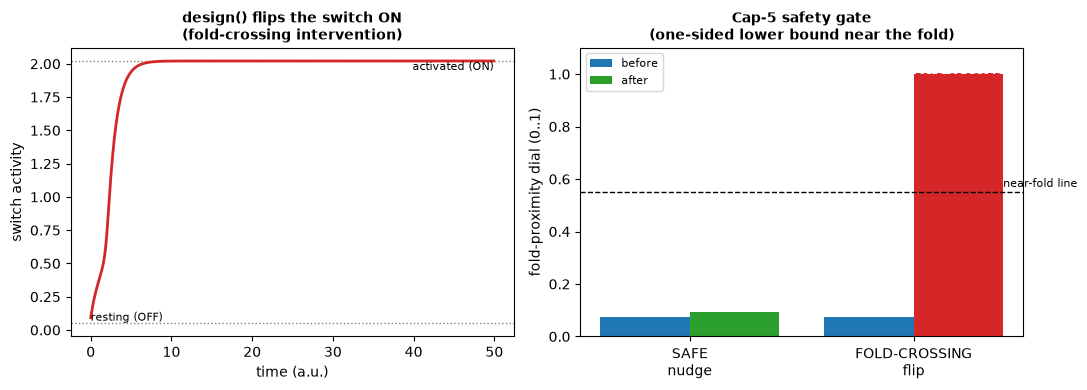

REASON (fold-crossing): proposed intervention: scale species[0].basal by x10.49 (3 knob(s) moved); closes 100% of the target gap — HIGH RISK OF INSTABILITY: the intervention CROSSES THE FOLD; switch loses bistability (NUDGE-LIM-013).


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# (left) the flip-ON trajectory (activity space).
traj = np.asarray(plan_risky.predicted_trajectory)[:, 0]
t = np.arange(traj.size) * 0.1
ax1.axhline(low,  ls=":", c="gray", lw=1); ax1.axhline(high, ls=":", c="gray", lw=1)
ax1.plot(t, traj, c="C3", lw=2)
ax1.annotate("resting (OFF)", (t[0], low), fontsize=8, va="bottom")
ax1.annotate("activated (ON)", (t[-1], high), fontsize=8, va="top", ha="right")
ax1.set_xlabel("time (a.u.)"); ax1.set_ylabel("switch activity")
ax1.set_title("design() flips the switch ON\n(fold-crossing intervention)", fontsize=10,
              fontweight="bold")

# (right) the safety dial: before vs after.
labels = ["SAFE\nnudge", "FOLD-CROSSING\nflip"]
before = [plan_safe.safety.proximity_before, plan_risky.safety.proximity_before]
after = [plan_safe.safety.proximity_after, plan_risky.safety.proximity_after]
x = np.arange(2)
ax2.bar(x - 0.2, before, 0.4, label="before", color="C0")
# fold crossed -> proximity is None (bistability lost); draw it as a full-height alarm bar.
after_plot = [a if a is not None else 1.0 for a in after]
colors = ["C2", "C3"]
ax2.bar(x + 0.2, after_plot, 0.4, label="after", color=colors)
ax2.axhline(0.55, ls="--", c="k", lw=1)
ax2.annotate("near-fold line", (1.4, 0.57), fontsize=8)
ax2.annotate("FOLD CROSSED\n(bistability lost)", (1.2, 1.01), fontsize=8, c="C3",
             ha="center", va="top")
ax2.set_xticks(x); ax2.set_xticklabels(labels)
ax2.set_ylabel("fold-proximity dial (0..1)")
ax2.set_title("Cap-5 safety gate\n(one-sided lower bound near the fold)", fontsize=10,
              fontweight="bold")
ax2.set_ylim(0, 1.1); ax2.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

print("REASON (fold-crossing):", plan_risky.reason)

### The honesty gates — abstain, don't guess

Two ways `design()` refuses rather than emit a confident-wrong proposal:
- **Integrity gate** — hand it an *unreliable* attribution and it declines up front.
- **Reachability gate** — ask for a state no intervention can reach and it abstains
  rather than extrapolate.

In [5]:
from nudge.inference.dose_response import DoseResponseResult, fit_dose_response

# Integrity gate: an 'unresolved' dose-response is not reliable to invert.
d = np.linspace(0.1, 5.0, 8); y = 0.5 + 0.01 * d
bad = DoseResponseResult(fit=fit_dose_response(d, y, n_boot=50), call="unresolved",
                         reason="curve is not Hill-like")
out_integrity = design(bad, 0.4)

# Reachability gate: a target far above any reachable state.
out_reach = design(CircuitFit(circuit=switch, free=[("edge", 0, "K")]),
                   np.asarray([1e6]), readout=readout, steps=300)

for label, out in [("integrity", out_integrity), ("reachability", out_reach)]:
    assert isinstance(out, AbstentionResult)
    print(f"[{label}]  ABSTAIN ({out.verdict.value})\n   {out.reason}\n")

[integrity]  ABSTAIN (unresolved)
   integrity gate: design() refuses to invert an unreliable attribution — curve is not Hill-like. Diagnose reliably before prescribing (never design off a fit you do not trust).

[reachability]  ABSTAIN (unresolved)
   reachability abstention: no intervention over the fitted knobs reached target within tolerance (closed 0% of the gap, need 95%). The target is unreachable within the fit's region — NUDGE will not extrapolate a proposal (NUDGE-LIM-013).



## Part B — REAL DATA: what knockdown dose achieves a target?

This is the real-data surface. On the OCT4/NANOG ESC Perturb-seq screen (Yao et al. 2025,
GSE283614), each OCT4 guide achieves a different fractional knockdown — so the guide axis
**is** a dose axis. NUDGE's `dose_response` fit already called **OCT4 → switch**
(`n≈6.7`, `R²=0.99`). Because that fit is *reliable*, `design()` can invert it: given a
target self-renewal level `y`, solve the Hill for the **knockdown dose** that achieves it.

There is **no circuit / fold here** — a dose-response curve is not a bistable circuit — so
curve mode carries **no safety gate**, and says so.

Point `OCT4_NANOG_H5AD` at your copy of the converted `ESC.h5ad` to run this section.

In [6]:
H5AD = os.environ.get("OCT4_NANOG_H5AD", "/media/nick/Seagate Hub/oct4_nanog/ESC.h5ad")
if not os.path.exists(H5AD):
    print(f"OCT4/NANOG ESC.h5ad not found at {H5AD} — set $OCT4_NANOG_H5AD. Skipping Part B.")
else:
    import anndata as ad
    from nudge.inference.bridge import knockdown_dose_response

    adata = ad.read_h5ad(H5AD)
    sig = ["SOX2", "LIN28A", "UTF1", "DNMT3B", "TDGF1", "ZFP42", "SALL4"]
    present = [g for g in sig if g in set(map(str, adata.var_names))]
    dose, resp = knockdown_dose_response(adata, target_gene="POU5F1", signature=present,
                                         group_prefix="OCT4")
    res = fit_dose_response(dose, resp, direction="repress", n_boot=1000, seed=0)
    oct4 = DoseResponseResult(fit=res, call="switch", reason="OCT4 -> switch (real data)")
    print(f"OCT4 fit: apparent gain n={res.n:.2f}  K={res.k_threshold:.2f}  R2={res.r2:.3f}")
    print(f"reliable to invert? {oct4.is_reliable}")
    print(f"self-renewal range: floor {res.floor:.2f} .. floor+amp {res.floor + res.amp:.2f}")

OCT4 fit: apparent gain n=6.74  K=0.65  R2=0.991
reliable to invert? True
self-renewal range: floor 0.24 .. floor+amp 0.98


### Invert to a dose — and abstain when out of range

We ask for a **reachable** target (a self-renewal level inside the fitted range) and an
**out-of-range** target (below the fully-silenced floor). The first returns a concrete
knockdown dose; the second is an honest **reachability abstention** — NUDGE will not
extrapolate a dose beyond the curve's saturating floor.

target self-renewal y = 0.684
  -> proposed OCT4 knockdown dose = 0.611 (fraction of POU5F1 silenced)
  safety gate: None   (curve mode: no circuit / fold to score)
  invert the repress Hill (apparent gain n=6.74, K=0.649): to reach response y=0.684, apply dose=0.611. Curve mode carries NO bifurcation safety gate — no circuit/fold to score (stated honestly).

target y = 0.043  ->  ABSTAIN (unresolved)
  reachability abstention: target y=0.043 is outside the curve's achievable range (0.243, 0.978) = (floor, floor+amp). No dose achieves it — NUDGE will not extrapolate beyond the fitted saturating asymptotes (NUDGE-LIM-013).


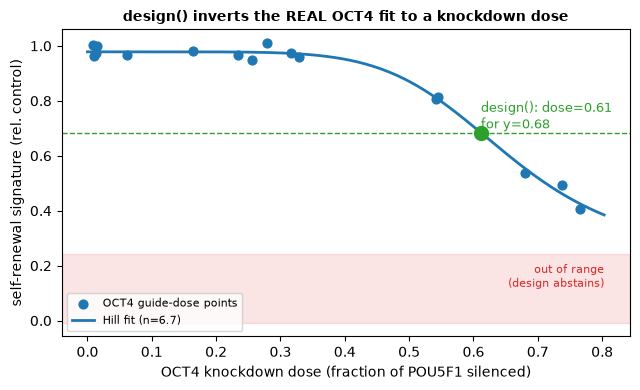

In [7]:
if os.path.exists(H5AD):
    # Reachable: drop self-renewal to 40% of the way down from baseline.
    y_reach = res.floor + 0.60 * res.amp
    plan = design(oct4, y_reach)
    assert isinstance(plan, InterventionPlan) and plan.mode == "dose"
    print(f"target self-renewal y = {y_reach:.3f}")
    print(f"  -> proposed OCT4 knockdown dose = {plan.dose:.3f} "
          f"(fraction of POU5F1 silenced)")
    print(f"  safety gate: {plan.safety}   (curve mode: no circuit / fold to score)")
    print(f"  {plan.reason}\n")

    # Out of range: below the fully-silenced floor -> abstain.
    out = design(oct4, res.floor - 0.2)
    assert isinstance(out, AbstentionResult)
    print(f"target y = {res.floor - 0.2:.3f}  ->  ABSTAIN ({out.verdict.value})")
    print(f"  {out.reason}")

    # Plot: the fitted curve, the inverted dose, and the out-of-range region.
    def hill_repress(dd, f):
        return f.floor + f.amp * f.k_threshold**f.n / (
            f.k_threshold**f.n + np.maximum(dd, 1e-9) ** f.n)
    xs = np.linspace(0, max(dose.max(), plan.dose) * 1.05, 200)
    fig, ax = plt.subplots(figsize=(6.5, 4))
    ax.scatter(dose, resp, s=40, c="C0", zorder=3, label="OCT4 guide-dose points")
    ax.plot(xs, hill_repress(xs, res), c="C0", lw=2, label=f"Hill fit (n={res.n:.1f})")
    ax.axhspan(res.floor - 0.25, res.floor, color="C3", alpha=0.12)
    ax.annotate("out of range\n(design abstains)", (xs[-1], res.floor - 0.12),
                fontsize=8, c="C3", ha="right")
    ax.axhline(y_reach, ls="--", c="C2", lw=1)
    ax.plot([plan.dose], [y_reach], "o", c="C2", ms=10, zorder=4)
    ax.annotate(f"design(): dose={plan.dose:.2f}\nfor y={y_reach:.2f}",
                (plan.dose, y_reach), fontsize=9, c="C2", va="bottom")
    ax.set_xlabel("OCT4 knockdown dose (fraction of POU5F1 silenced)")
    ax.set_ylabel("self-renewal signature (rel. control)")
    ax.set_title("design() inverts the REAL OCT4 fit to a knockdown dose",
                 fontsize=10, fontweight="bold")
    ax.legend(loc="lower left", fontsize=8)
    plt.tight_layout(); plt.show()

## What this buys

`design()` closes NUDGE's loop: **diagnose → prescribe**. It is the same differentiable
circuit run backwards, kept honest by:
- an **integrity gate** (never design off an unreliable fit),
- a **reachability abstention** (never extrapolate to an unreachable target),
- a **bifurcation safety gate** (flag an intervention that pushes a switch toward its
  tipping point — a one-sided lower bound near the fold, `NUDGE-LIM-012`), stated as
  *absent* in curve mode rather than silently skipped.

Every proposal is a **model-bound hypothesis to test**, valid only within the fit's
identifiable region (`NUDGE-LIM-013`) — never a guaranteed outcome.

**Reproduce it:**
```bash
# circuit mode (synthetic switch, with the safety gate)
nudge design --topology 1node --to high

# curve mode (real dose-response -> a dose)
nudge design curve.csv --target-response 0.5
```
or the `design` MCP tool. See the Mechanism Card `NUDGE-METHOD-007` (`inverse_design`).